# Assignment 1: Demand Forecasting
## EDA and Modeling

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
import joblib
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = Path.cwd()
SOURCE_DATA = PROJECT_DIR.parent / 'data' / 'raw' / 'Utility_consumption.csv'
if not SOURCE_DATA.exists():
    raise FileNotFoundError('Utility_consumption.csv was not found at data/raw/Utility_consumption.csv.')
df = pd.read_csv(SOURCE_DATA)
df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed')
df = df.set_index('Datetime').sort_index()

FEEDER_COLS = [c for c in df.columns if 'PowerConsumption' in c]
print(f"Feeder cols: {FEEDER_COLS}")


Feeder cols: ['F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption']


### Weather Data

In [10]:
# Fetching Open-Meteo Data
import requests
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 23.7957, "longitude": 86.4304,
    "start_date": "2017-01-01", "end_date": "2017-12-30",
    "hourly": "temperature_2m,relative_humidity_2m,cloudcover,windspeed_10m",
    "timezone": "Asia/Kolkata"
}
weather_data = requests.get(url, params=params).json()

weather_df = pd.DataFrame({
    'timestamp': pd.to_datetime(weather_data['hourly']['time']),
    'temperature': weather_data['hourly']['temperature_2m'],
    'humidity': weather_data['hourly']['relative_humidity_2m'],
    'cloud_cover': weather_data['hourly']['cloudcover'],
    'wind_speed': weather_data['hourly']['windspeed_10m']
})
weather_30min = weather_df.set_index('timestamp').resample('30min').interpolate(method='linear')


### EDA: Exploratory Data Analysis
Let's analyze the raw data, distributions, and correlations before cleaning.

        Temperature      Humidity     WindSpeed  F1_132KV_PowerConsumption  \
count  52416.000000  52416.000000  52416.000000               52416.000000   
mean      18.810024     68.259518      1.959489               32344.970564   
std        5.815476     15.551177      2.348862                7130.562564   
min        3.247000     11.340000      0.050000               13895.696200   
25%       14.410000     58.310000      0.078000               26310.668692   
50%       18.780000     69.860000      0.086000               32265.920340   
75%       22.890000     81.400000      4.915000               37309.018185   
max       40.010000     94.800000      6.483000               52204.395120   

       F2_132KV_PowerConsumption  F3_132KV_PowerConsumption           load  \
count               52416.000000               52416.000000   52416.000000   
mean                21042.509082               17835.406218   71222.885864   
std                  5201.465892                6622.165099   1

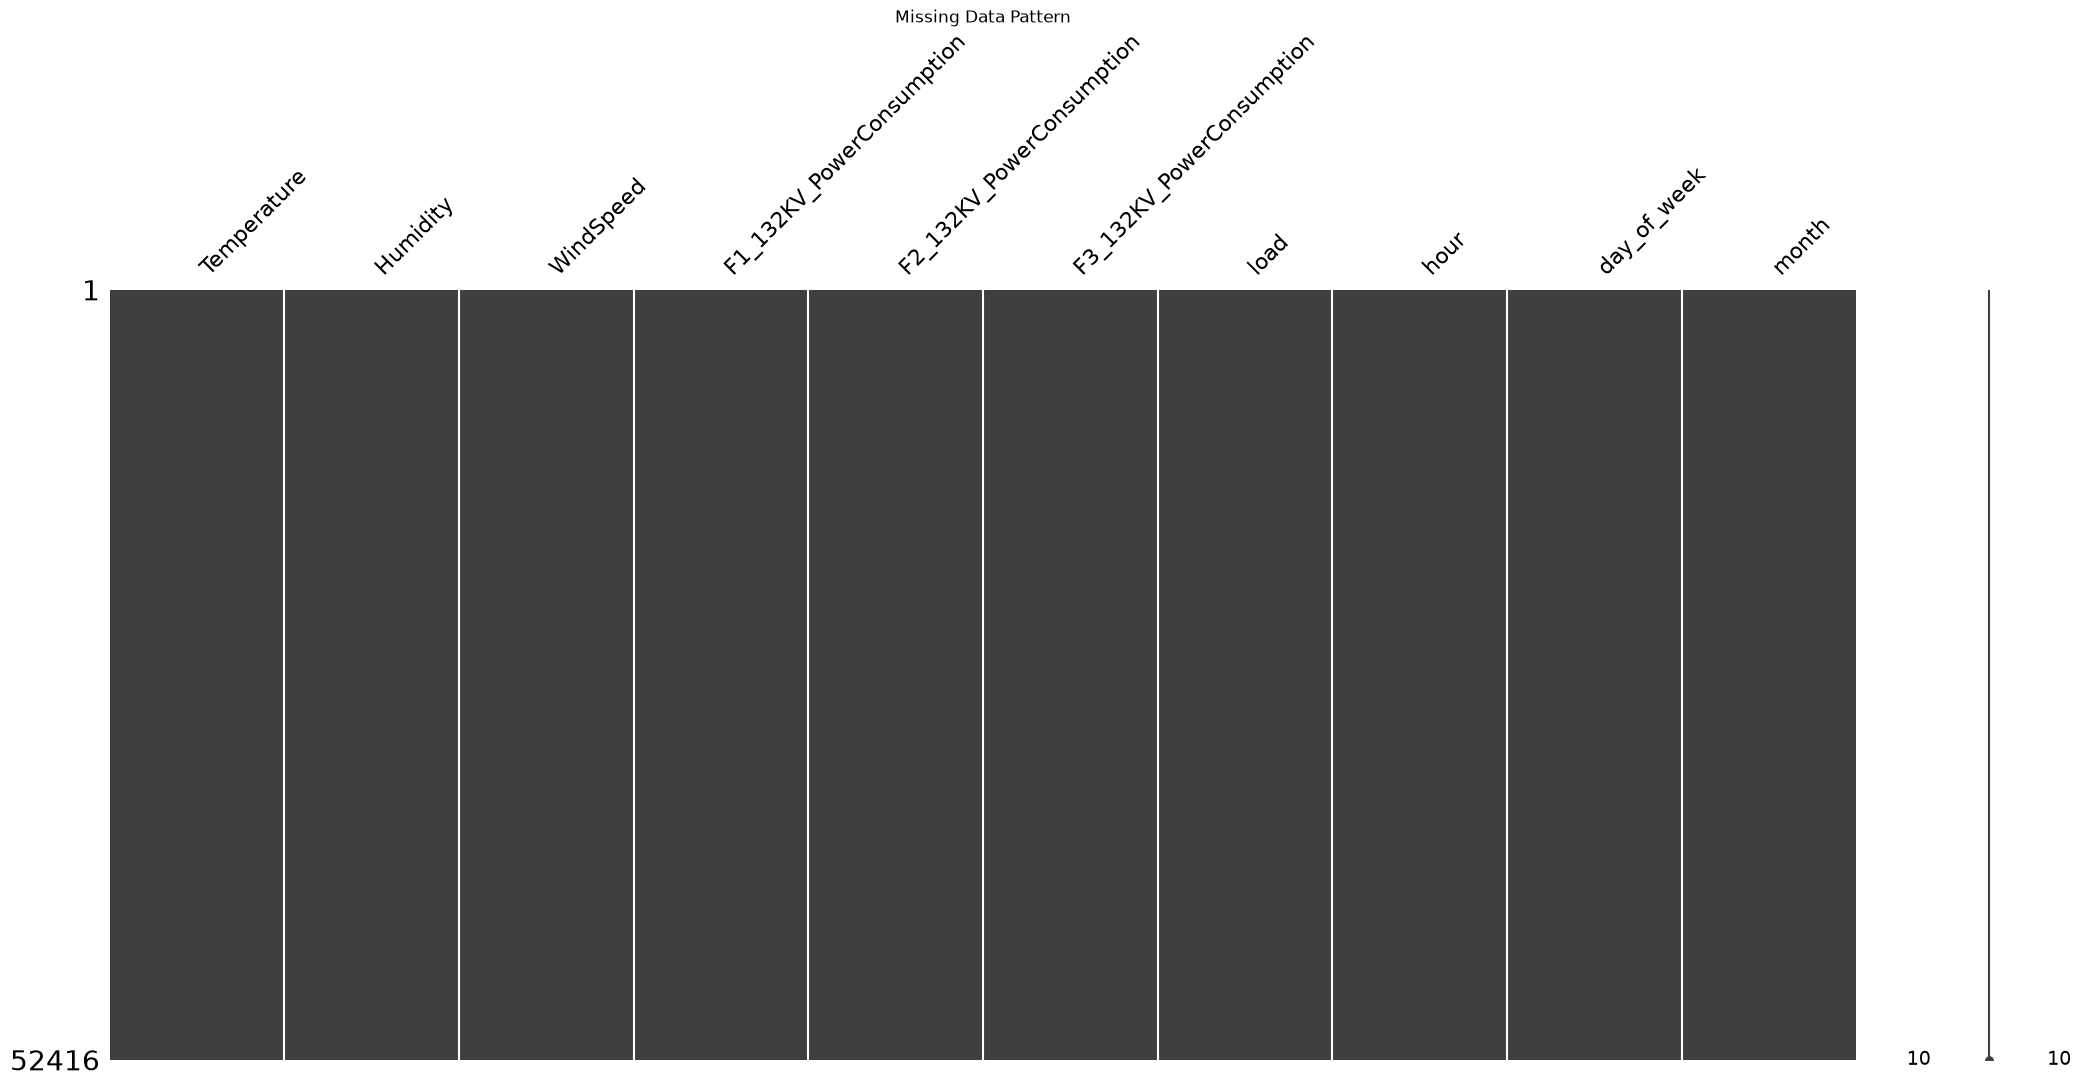

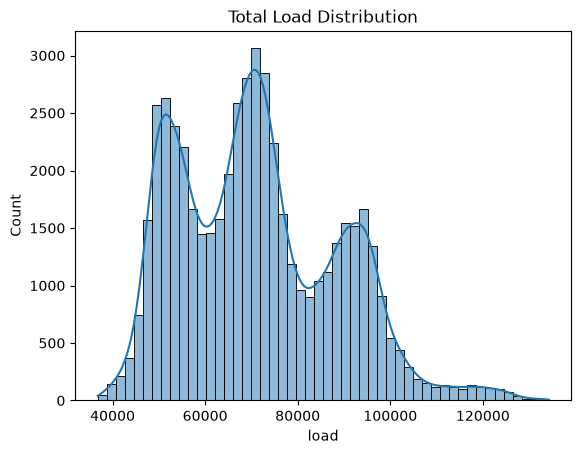

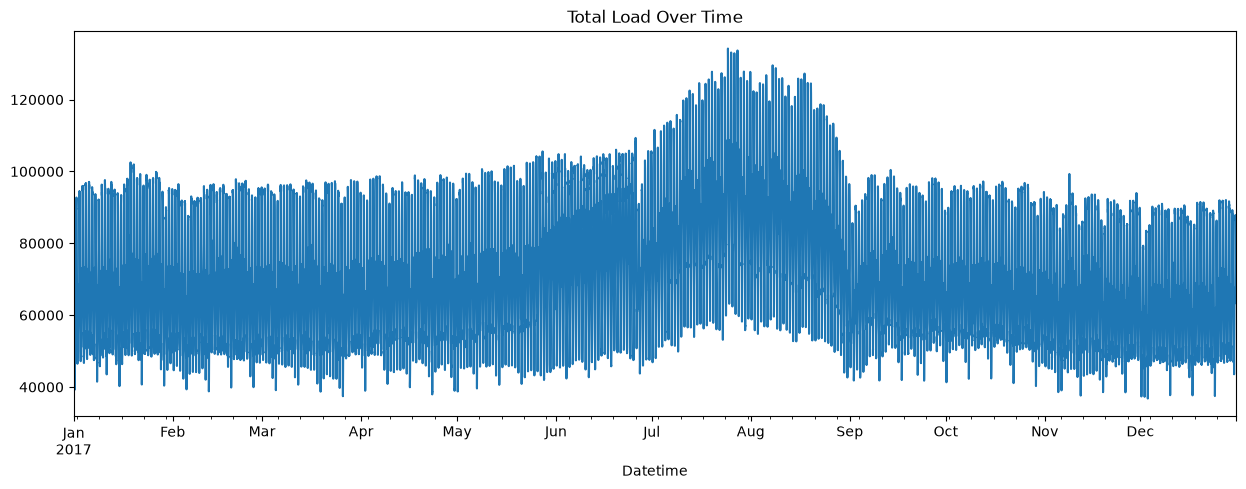

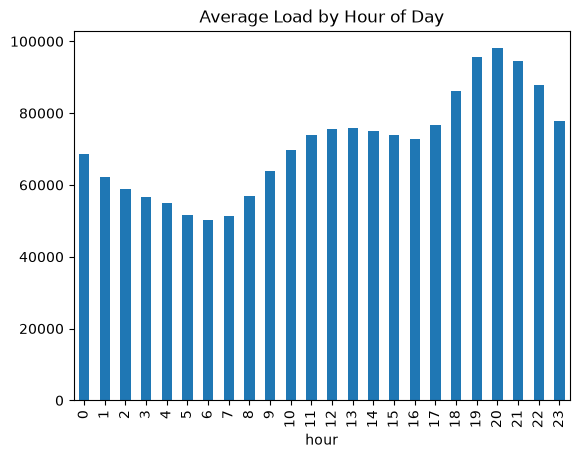

In [11]:
import missingno as msno

eda = df.copy()
eda['load'] = eda[FEEDER_COLS].sum(axis=1)
eda['hour'] = eda.index.hour
eda['day_of_week'] = eda.index.dayofweek
eda['month'] = eda.index.month

print(eda.describe())
print(eda.isnull().sum())

# Missing data pattern
msno.matrix(eda)
plt.title("Missing Data Pattern")
plt.show()

# Load distribution
sns.histplot(eda['load'], bins=50, kde=True)
plt.title("Total Load Distribution")
plt.show()

# Load over time
eda['load'].plot(figsize=(15, 5))
plt.title("Total Load Over Time")
plt.show()

# Average Load by Hour
eda.groupby('hour')['load'].mean().plot(kind='bar')
plt.title("Average Load by Hour of Day")
plt.show()


### EDA: Weather & Holidays Impact

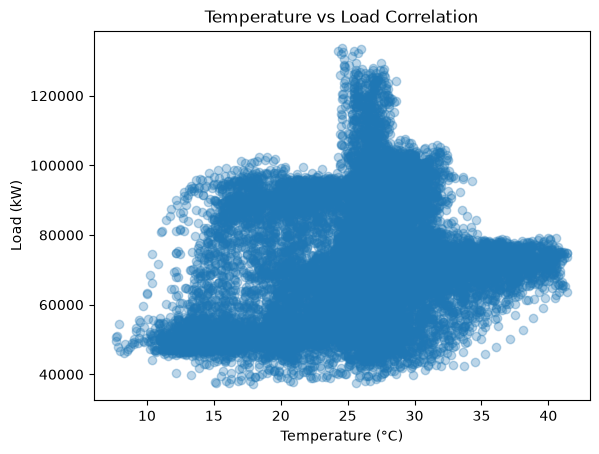

Correlation Matrix:
                 load  temperature  humidity  cloud_cover  wind_speed
load         1.000000     0.254707  0.012403     0.297811    0.149648
temperature  0.254707     1.000000 -0.357095     0.276170    0.167238
humidity     0.012403    -0.357095  1.000000     0.454014   -0.219874
cloud_cover  0.297811     0.276170  0.454014     1.000000    0.013772
wind_speed   0.149648     0.167238 -0.219874     0.013772    1.000000


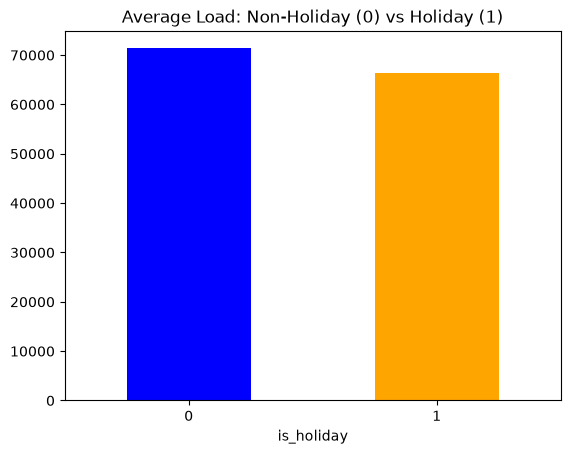

In [12]:
combined = eda[['load']].resample('30min').mean().join(weather_30min)

# Temperature vs Load
plt.scatter(combined['temperature'], combined['load'], alpha=0.3)
plt.xlabel("Temperature (°C)")
plt.ylabel("Load (kW)")
plt.title("Temperature vs Load Correlation")
plt.show()

# Correlation Matrix
print("Correlation Matrix:")
print(combined.corr())

# Holiday impact
holiday_dates = pd.to_datetime(pd.read_csv('../data/raw/jharkhand_holidays.csv')['date']).dt.normalize()
combined['is_holiday'] = combined.index.normalize().isin(holiday_dates).astype(int)
combined.groupby('is_holiday')['load'].mean().plot(kind='bar', color=['blue', 'orange'])
plt.title("Average Load: Non-Holiday (0) vs Holiday (1)")
plt.xticks(rotation=0)
plt.show()


### Target Creation and Clipping

In [13]:
df_clean = df.copy()
df_clean['load'] = df_clean[FEEDER_COLS].sum(axis=1, min_count=len(FEEDER_COLS))
df_clean = df_clean[['load']].interpolate(method='time', limit=3)

def grouped_clip(series):
    month = series.index.month
    hour = series.index.hour
    is_weekend = series.index.dayofweek >= 5
    result = series.copy()
    for m in range(1, 13):
        for h in range(24):
            for w in [True, False]:
                mask = (month == m) & (hour == h) & (is_weekend == w)
                if mask.sum() < 4: continue
                s = series[mask]
                Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
                IQR = Q3 - Q1
                result[mask] = s.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    return result

df_clean['load'] = grouped_clip(df_clean['load'])
df_30min = df_clean.resample('30min').mean()
df_30min['load'] = df_30min['load'].fillna(df_30min['load'].shift(336)).ffill().bfill()


### Feature Engineering

In [14]:
df_feat = df_30min.copy()
df_feat['hour'] = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['quarter'] = df_feat.index.quarter
df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
df_feat['week_of_year'] = df_feat.index.isocalendar().week.astype(int)

df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)

holiday_dates = pd.to_datetime(pd.read_csv('../data/raw/jharkhand_holidays.csv')['date']).dt.normalize()
df_feat['is_holiday'] = df_feat.index.normalize().isin(holiday_dates).astype(int)

df_feat['lag_48'] = df_feat['load'].shift(48)
df_feat['lag_96'] = df_feat['load'].shift(96)
df_feat['lag_336'] = df_feat['load'].shift(336)

df_feat = df_feat.join(weather_30min, how='left')
for c in ['temperature', 'humidity', 'cloud_cover', 'wind_speed']:
    df_feat[c] = df_feat[c].ffill().bfill()

df_feat['temp_x_humidity'] = df_feat['temperature'] * df_feat['humidity']
df_feat['feels_like'] = df_feat['temperature'] - 0.55 * (1 - df_feat['humidity']/100) * (df_feat['temperature'] - 14.5)
df_feat = df_feat.dropna()


### Candidate Model Comparison
We compare a mean baseline, Linear Regression, and Random Forest on the same time-based test split. The final API uses Random Forest because it captures non-linear daily demand, weather interaction, and lag effects without requiring a larger deep-learning dataset.

In [15]:
FEATURES = [
    'hour', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_holiday',
    'temperature', 'humidity', 'cloud_cover', 'wind_speed',
    'temp_x_humidity', 'feels_like', 'lag_48', 'lag_96', 'lag_336'
]
TARGET = 'load'

n = len(df_feat)
train_df = df_feat.iloc[:int(n * 0.70)]
val_df   = df_feat.iloc[int(n * 0.70):int(n * 0.85)]
test_df  = df_feat.iloc[int(n * 0.85):]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

def mape_percent(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

candidates = {
    'mean_baseline': DummyRegressor(strategy='mean'),
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
}

rows = []
fitted_models = {}
for name, candidate in candidates.items():
    candidate.fit(X_train, y_train)
    preds = candidate.predict(X_test)
    rows.append({
        'model': name,
        'mae': mean_absolute_error(y_test, preds),
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mape_percent': mape_percent(y_test, preds),
        'r2': r2_score(y_test, preds),
    })
    fitted_models[name] = candidate

comparison_df = pd.DataFrame(rows).sort_values('mae')
display(comparison_df)

model = fitted_models['random_forest']

import joblib
joblib.dump(model, '../models/forecast_model.joblib')
comparison_df.to_csv('../models/model_comparison.csv', index=False)


,model,mae,rmse,mape_percent,r2
2,random_forest,1530.844716,2198.926467,2.358379,0.976101
1,linear_regression,1575.918411,2152.431466,2.539719,0.977101
0,mean_baseline,14590.772055,16848.582394,25.967503,-0.403069


### Evaluation

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score
preds = model.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, preds))
print("Test MAPE (%):", mape_percent(y_test, preds))
print("Test R2:", r2_score(y_test, preds))


Test MAE: 1530.8447159289424
Test MAPE (%): 2.3583792256963
Test R2: 0.9761013338881384
